In [306]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [307]:
df = pd.read_csv("train.csv")

In [308]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.0708,NaN,C


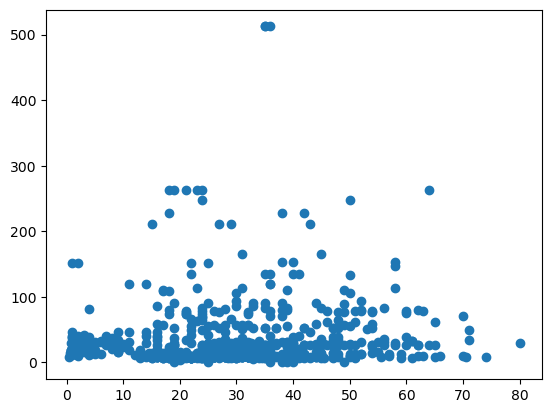

In [309]:
plt.scatter(df["Age"], df["Fare"])

In [310]:
# Extract the title (Mr, Mrs, Miss, ...) sitting between the comma and the period
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.")

# See what we got
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

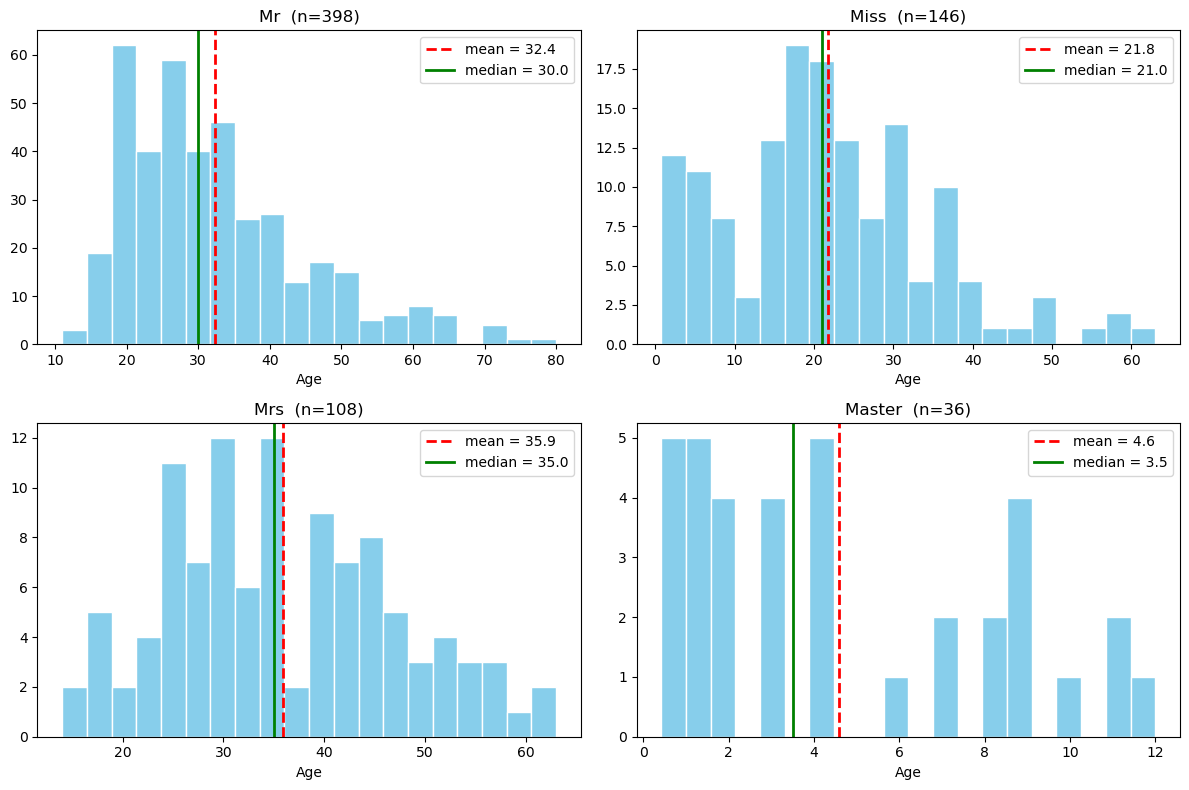

,mean,median,count
Title,,,
Capt,70.000000,70.0,1
Col,58.000000,58.0,2
Countess,33.000000,33.0,1
Don,40.000000,40.0,1
Dr,42.000000,46.5,6
Jonkheer,38.000000,38.0,1
Lady,48.000000,48.0,1
Major,48.500000,48.5,2
Master,4.574167,3.5,36


In [311]:
# Why median over mean? Outliers (very old / very young) pull the MEAN, the MEDIAN barely moves.
# Plot the age distribution per title with both marked.
main_titles = ["Mr", "Miss", "Mrs", "Master"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, title in zip(axes.flat, main_titles):
    ages = df.loc[df["Title"] == title, "Age"].dropna()
    ax.hist(ages, bins=20, color="skyblue", edgecolor="white")
    ax.axvline(ages.mean(),   color="red",   linestyle="--", linewidth=2, label=f"mean = {ages.mean():.1f}")
    ax.axvline(ages.median(), color="green", linestyle="-",  linewidth=2, label=f"median = {ages.median():.1f}")
    ax.set_title(f"{title}  (n={len(ages)})")
    ax.set_xlabel("Age")
    ax.legend()
plt.tight_layout()
plt.show()

# Numbers behind the plot
df.groupby("Title")["Age"].agg(["mean", "median", "count"])

In [312]:
# Fill missing Age with the MEDIAN age of each Title group (fine-grained: Mr / Mrs / Miss / Master / ...)
print("Missing ages before:", df["Age"].isna().sum())

df["Age"] = df.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))

print("Missing ages after: ", df["Age"].isna().sum())

Missing ages before: 177
Missing ages after:  0


In [313]:
# --- Investigate the Cabin deck letter before deciding to use/drop it ---
df["Deck"] = df["Cabin"].str[0]   # first letter; NaN stays NaN

# Hypothesis 1: is a deck recorded mostly for Pclass 1?
print("Deck (rows) vs Pclass (cols):")
print(pd.crosstab(df["Deck"], df["Pclass"]))

# Hypothesis 2: does a 'higher' letter (A>B>C...) mean higher survival?
print("\nSurvival rate by deck (and how many people):")
print(df.groupby("Deck")["Survived"].agg(["mean", "count"]))

Deck (rows) vs Pclass (cols):
Pclass   1  2  3
Deck            
A       15  0  0
B       47  0  0
C       59  0  0
D       29  4  0
E       25  4  3
F        0  8  5
G        0  0  4
T        1  0  0

Survival rate by deck (and how many people):
          mean  count
Deck                 
A     0.466667     15
B     0.744681     47
C     0.593220     59
D     0.757576     33
E     0.750000     32
F     0.615385     13
G     0.500000      4
T     0.000000      1


In [314]:
# Family features from SibSp + Parch
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1          # +1 = the person themselves
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)       # 1 = traveling alone

df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [315]:
# Encode Sex as binary: female = 0, male = 1
df["Sex"] = (df["Sex"] == "male").astype(int)

df["Sex"].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [316]:
# Embarked -> three dummy columns (S, C, Q). Fill the 2 missing with the most common port first.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked").astype(int)
df = pd.concat([df, embarked_dummies], axis=1)

embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [317]:
# Pclass -> three dummy columns (1, 2, 3)
pclass_dummies = pd.get_dummies(df["Pclass"], prefix="Pclass").astype(int)
df = pd.concat([df, pclass_dummies], axis=1)

pclass_dummies.head()

,Pclass_1,Pclass_2,Pclass_3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1


In [318]:
# Drop Ticket: messy alphanumeric codes, no clean signal for a linear model
df = df.drop(columns=["Ticket"])

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Cabin', 'Embarked', 'Title', 'Deck', 'FamilySize',
       'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1',
       'Pclass_2', 'Pclass_3'],
      dtype='object')

In [319]:
# --- First linear regression: class, sex, age, family size, fare -> survival ---
# Pclass_1 is the baseline (in the intercept), so we use only Pclass_2 and Pclass_3.
features = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare"]

X = df[features]
y = df["Survived"]

model = LinearRegression()
model.fit(X, y)

# Look at what the line learned
print("Intercept:", round(model.intercept_, 4))
print(pd.Series(model.coef_, index=features).round(4))

# Regression outputs a number, not 0/1 -- peek at the range
preds = model.predict(X)
print("\nPrediction range: %.3f to %.3f" % (preds.min(), preds.max()))

Intercept: 1.1766
Pclass_2     -0.1631
Pclass_3     -0.3461
Sex          -0.5107
Age          -0.0062
FamilySize   -0.0365
Fare          0.0005
dtype: float64

Prediction range: -0.237 to 1.155


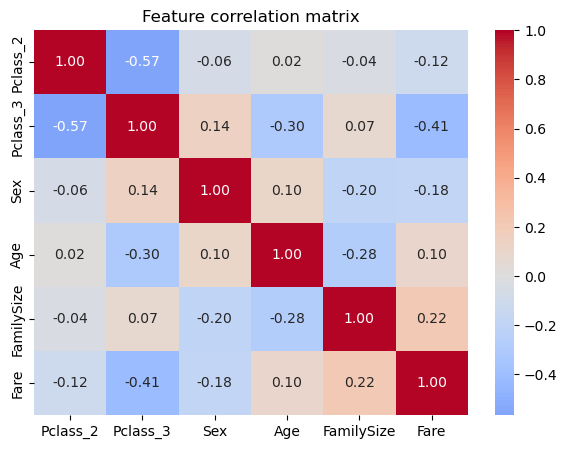

VIF per feature:
Pclass_3      2.67
Pclass_2      2.02
Fare          1.73
Age           1.26
FamilySize    1.21
Sex           1.09
dtype: float64


In [320]:
# --- Multicollinearity check (no statsmodels needed) ---

# 1) Correlation heatmap of the features
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature correlation matrix")
plt.show()

# 2) VIF computed by hand: regress each feature on the others, VIF = 1 / (1 - R^2)
#    Rule of thumb: VIF > 5 is worth a look, > 10 is serious multicollinearity.
vif = {}
for col in features:
    others = [c for c in features if c != col]
    r2 = LinearRegression().fit(X[others], X[col]).score(X[others], X[col])
    vif[col] = 1 / (1 - r2)

print("VIF per feature:")
print(pd.Series(vif).round(2).sort_values(ascending=False))

Training accuracy at cutoff 0.5: 0.798


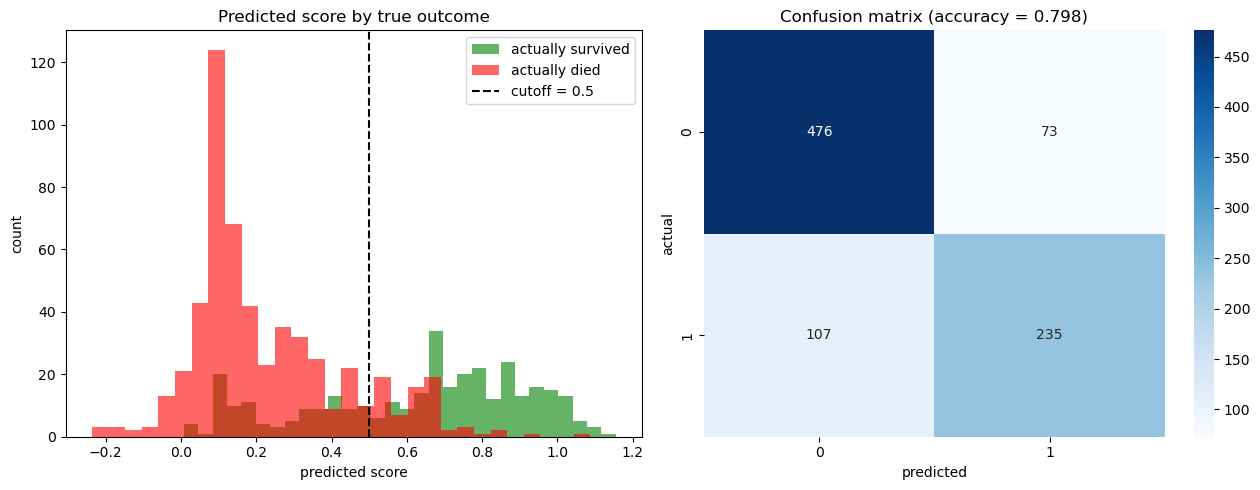

In [321]:
# --- How well did the model predict? Cutoff at 0.5: >= 0.5 -> 1, else 0 ---
cutoff = 0.5
y_pred = (preds >= cutoff).astype(int)

accuracy = (y_pred == y).mean()
print(f"Training accuracy at cutoff {cutoff}: {accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) Distribution of the regression score, split by the TRUE outcome.
#     Good separation around the cutoff = good model.
axes[0].hist(preds[y == 1], bins=30, alpha=0.6, color="green", label="actually survived")
axes[0].hist(preds[y == 0], bins=30, alpha=0.6, color="red",   label="actually died")
axes[0].axvline(cutoff, color="black", linestyle="--", label=f"cutoff = {cutoff}")
axes[0].set_xlabel("predicted score")
axes[0].set_ylabel("count")
axes[0].set_title("Predicted score by true outcome")
axes[0].legend()

# (2) Confusion matrix: where it was right vs wrong
cm = pd.crosstab(y, y_pred, rownames=["actual"], colnames=["predicted"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title(f"Confusion matrix (accuracy = {accuracy:.3f})")

plt.tight_layout()
plt.show()

cutoff 0.500 -> accuracy 0.7980
cutoff 0.525 -> accuracy 0.7980
cutoff 0.550 -> accuracy 0.8036
cutoff 0.575 -> accuracy 0.8092
cutoff 0.600 -> accuracy 0.8058

Best cutoff here: 0.575  (accuracy 0.8092)


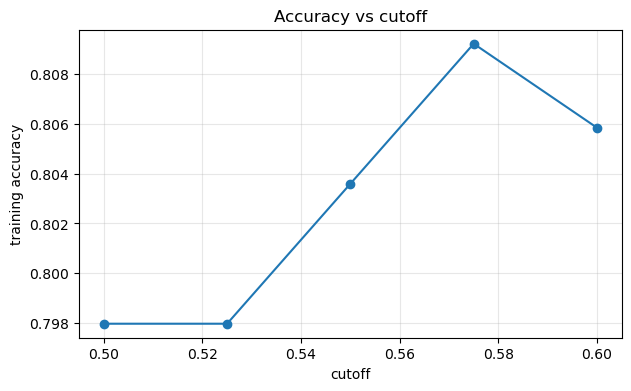

In [322]:
# --- Try several cutoffs and compare training accuracy ---
cutoffs = [0.5, 0.525, 0.55, 0.575, 0.6]
results = {}
for c in cutoffs:
    acc = ((preds >= c).astype(int) == y).mean()
    results[c] = acc
    print(f"cutoff {c:.3f} -> accuracy {acc:.4f}")

best = max(results, key=results.get)
print(f"\nBest cutoff here: {best}  (accuracy {results[best]:.4f})")

plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), list(results.values()), marker="o")
plt.xlabel("cutoff")
plt.ylabel("training accuracy")
plt.title("Accuracy vs cutoff")
plt.grid(True, alpha=0.3)
plt.show()

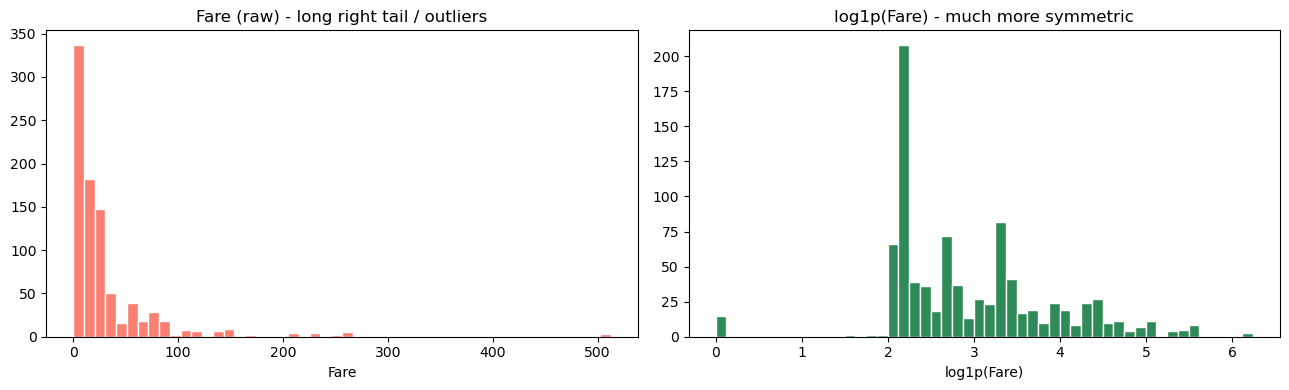

Coefficients: raw vs standardized (sorted by standardized importance)
            raw_coef  standardized_coef
Sex          -0.5107            -0.2440
Pclass_3     -0.3461            -0.1721
Age          -0.0062            -0.0824
Pclass_2     -0.1631            -0.0660
FamilySize   -0.0365            -0.0588
Fare          0.0005             0.0225


In [323]:
# --- Fare diagnostic: is the tiny coefficient about scale + skew, not importance? ---
from sklearn.preprocessing import StandardScaler

# (a) See the skew/outliers: raw Fare vs log1p(Fare)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["Fare"], bins=50, color="salmon", edgecolor="white")
axes[0].set_title("Fare (raw) - long right tail / outliers")
axes[0].set_xlabel("Fare")
axes[1].hist(np.log1p(df["Fare"]), bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("log1p(Fare) - much more symmetric")
axes[1].set_xlabel("log1p(Fare)")
plt.tight_layout()
plt.show()

# (b) Refit on STANDARDIZED features (mean 0, std 1) so coefficients are comparable.
#     Now each coef = effect of a 1-standard-deviation change -> apples to apples.
X_std = StandardScaler().fit_transform(X)
model_std = LinearRegression().fit(X_std, y)

comparison = pd.DataFrame(
    {"raw_coef": model.coef_, "standardized_coef": model_std.coef_},
    index=features,
)
print("Coefficients: raw vs standardized (sorted by standardized importance)")
print(comparison.round(4).reindex(comparison["standardized_coef"].abs().sort_values(ascending=False).index))

In [324]:
# --- Interaction term: Sex x Pclass (class hurt women far more than men) ---
df["Sex_x_Pclass2"] = df["Sex"] * df["Pclass_2"]
df["Sex_x_Pclass3"] = df["Sex"] * df["Pclass_3"]

features_int = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare",
                "Sex_x_Pclass2", "Sex_x_Pclass3"]
X_int = df[features_int]

model_int = LinearRegression().fit(X_int, y)
preds_int = model_int.predict(X_int)

print("Coefficients (with interaction):")
print(pd.Series(model_int.coef_, index=features_int).round(4))
print("\nPrediction range: %.3f to %.3f" % (preds_int.min(), preds_int.max()))

Coefficients (with interaction):
Pclass_2        -0.0542
Pclass_3        -0.4924
Sex             -0.5683
Age             -0.0064
FamilySize      -0.0328
Fare             0.0003
Sex_x_Pclass2   -0.1982
Sex_x_Pclass3    0.2032
dtype: float64

Prediction range: -0.168 to 1.134


In [325]:
# Cutoff sweep WITH the interaction, side by side against the no-interaction model
print(f"{'cutoff':>8} | {'no-interaction':>15} | {'Sex x Pclass':>14}")
print("-" * 43)
for c in [0.5, 0.525, 0.55, 0.575, 0.6]:
    acc_old = ((preds     >= c).astype(int) == y).mean()
    acc_new = ((preds_int >= c).astype(int) == y).mean()
    print(f"{c:8.3f} | {acc_old:15.4f} | {acc_new:14.4f}")

  cutoff |  no-interaction |   Sex x Pclass
-------------------------------------------
   0.500 |          0.7980 |         0.8058
   0.525 |          0.7980 |         0.8137
   0.550 |          0.8036 |         0.8126
   0.575 |          0.8092 |         0.7980
   0.600 |          0.8058 |         0.7946


In [326]:
# --- Add Sex x Age on top of Sex x Pclass ("women & children first": age acts differently by sex) ---
df["Sex_x_Age"] = df["Sex"] * df["Age"]

features_int2 = features_int + ["Sex_x_Age"]
X_int2 = df[features_int2]

model_int2 = LinearRegression().fit(X_int2, y)
preds_int2 = model_int2.predict(X_int2)

print("Coefficients (Sex x Pclass + Sex x Age):")
print(pd.Series(model_int2.coef_, index=features_int2).round(4))
print("\nPrediction range: %.3f to %.3f" % (preds_int2.min(), preds_int2.max()))

Coefficients (Sex x Pclass + Sex x Age):
Pclass_2        -0.0339
Pclass_3        -0.4509
Sex             -0.3825
Age             -0.0030
FamilySize      -0.0343
Fare             0.0003
Sex_x_Pclass2   -0.2343
Sex_x_Pclass3    0.1397
Sex_x_Age       -0.0051
dtype: float64

Prediction range: -0.225 to 1.139


In [327]:
# Cutoff sweep: Sex x Pclass  vs  Sex x Pclass + Sex x Age
print(f"{'cutoff':>8} | {'Sex x Pclass':>14} | {'+ Sex x Age':>14}")
print("-" * 43)
for c in [0.5, 0.525, 0.55, 0.575, 0.6]:
    acc_a = ((preds_int  >= c).astype(int) == y).mean()
    acc_b = ((preds_int2 >= c).astype(int) == y).mean()
    print(f"{c:8.3f} | {acc_a:14.4f} | {acc_b:14.4f}")

  cutoff |   Sex x Pclass |    + Sex x Age
-------------------------------------------
   0.500 |         0.8058 |         0.8070
   0.525 |         0.8137 |         0.8092
   0.550 |         0.8126 |         0.8081
   0.575 |         0.7980 |         0.7946
   0.600 |         0.7946 |         0.7901


In [328]:
# --- Try all four interactions one by one, then every combination, ranked by best accuracy ---
import itertools

# Build every candidate interaction column (Pclass interactions use the two dummies, like the base)
df["Sex_x_Pclass2"]    = df["Sex"] * df["Pclass_2"]
df["Sex_x_Pclass3"]    = df["Sex"] * df["Pclass_3"]
df["Sex_x_Age"]        = df["Sex"] * df["Age"]
df["Pclass2_x_Age"]    = df["Pclass_2"] * df["Age"]
df["Pclass3_x_Age"]    = df["Pclass_3"] * df["Age"]
df["Sex_x_FamilySize"] = df["Sex"] * df["FamilySize"]

base = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare"]
interactions = {
    "Sex x Pclass":     ["Sex_x_Pclass2", "Sex_x_Pclass3"],
    "Sex x Age":        ["Sex_x_Age"],
    "Pclass x Age":     ["Pclass2_x_Age", "Pclass3_x_Age"],
    "Sex x FamilySize": ["Sex_x_FamilySize"],
}
cutoffs = [0.5, 0.525, 0.55, 0.575, 0.6]
names = list(interactions.keys())

rows = []
for r in range(len(names) + 1):                       # r = 0 (base) ... 4 (all)
    for combo in itertools.combinations(names, r):
        cols = base + [c for nm in combo for c in interactions[nm]]
        p = LinearRegression().fit(df[cols], y).predict(df[cols])
        best_acc, best_c = max(((((p >= c).astype(int) == y).mean(), c) for c in cutoffs))
        rows.append({
            "interactions": " + ".join(combo) if combo else "(base only)",
            "n_added": r,
            "best_cutoff": best_c,
            "best_acc": round(best_acc, 4),
        })

res = pd.DataFrame(rows).sort_values("best_acc", ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", None)
res

,interactions,n_added,best_cutoff,best_acc
0,Sex x Age + Pclass x Age,2,0.525,0.8193
1,Sex x Age + Pclass x Age + Sex x FamilySize,3,0.500,0.8193
2,Sex x Pclass + Sex x FamilySize,2,0.525,0.8159
3,Sex x FamilySize,1,0.550,0.8148
4,Pclass x Age + Sex x FamilySize,2,0.500,0.8148
5,Sex x Pclass,1,0.525,0.8137
6,Sex x Pclass + Sex x Age + Pclass x Age,3,0.525,0.8137
7,Sex x Pclass + Pclass x Age + Sex x FamilySize,3,0.525,0.8137
8,Sex x Age + Sex x FamilySize,2,0.525,0.8126
9,Sex x Pclass + Sex x Age + Sex x FamilySize,3,0.550,0.8126


In [329]:
cols_A = base + interactions["Sex x Age"] + interactions["Pclass x Age"]
cols_B = cols_A + interactions["Sex x FamilySize"]
pA = LinearRegression().fit(df[cols_A], y).predict(df[cols_A])
pB = LinearRegression().fit(df[cols_B], y).predict(df[cols_B])
import numpy as np
for c in np.arange(0.45, 0.601, 0.005):
    aA = ((pA >= c).astype(int) == y).mean()
    aB = ((pB >= c).astype(int) == y).mean()
    print(f"{c:.3f} | A {aA:.16f} | B {aB:.16f}")

0.450 | A 0.8069584736251403 | B 0.8193041526374860
0.455 | A 0.8092031425364759 | B 0.8181818181818182
0.460 | A 0.8092031425364759 | B 0.8170594837261503
0.465 | A 0.8080808080808081 | B 0.8159371492704826
0.470 | A 0.8080808080808081 | B 0.8148148148148148
0.475 | A 0.8092031425364759 | B 0.8136924803591470
0.480 | A 0.8092031425364759 | B 0.8148148148148148
0.485 | A 0.8092031425364759 | B 0.8170594837261503
0.490 | A 0.8103254769921436 | B 0.8170594837261503
0.495 | A 0.8092031425364759 | B 0.8181818181818182
0.500 | A 0.8125701459034792 | B 0.8193041526374860
0.505 | A 0.8148148148148148 | B 0.8193041526374860
0.510 | A 0.8148148148148148 | B 0.8181818181818182
0.515 | A 0.8159371492704826 | B 0.8204264870931538
0.520 | A 0.8181818181818182 | B 0.8181818181818182
0.525 | A 0.8193041526374860 | B 0.8181818181818182
0.530 | A 0.8181818181818182 | B 0.8204264870931538
0.535 | A 0.8181818181818182 | B 0.8193041526374860
0.540 | A 0.8193041526374860 | B 0.8181818181818182
0.545 | A 0.

In [330]:
rows = []
for c in np.arange(0.45, 0.601, 0.005):
    aA = ((pA >= c).astype(int) == y).mean()
    aB = ((pB >= c).astype(int) == y).mean()
    rows.append({"cutoff": round(c, 3), "accA": aA, "accB": aB, "best": max(aA, aB)})

res2 = pd.DataFrame(rows).sort_values("best", ascending=False).reset_index(drop=True)
print(res2.to_string(index=False))

print(res2[res2["best"] == res2["best"].max()].to_string(index=False))

 cutoff     accA     accB     best
  0.530 0.818182 0.820426 0.820426
  0.515 0.815937 0.820426 0.820426
  0.450 0.806958 0.819304 0.819304
  0.500 0.812570 0.819304 0.819304
  0.545 0.819304 0.818182 0.819304
  0.540 0.819304 0.818182 0.819304
  0.535 0.818182 0.819304 0.819304
  0.505 0.814815 0.819304 0.819304
  0.525 0.819304 0.818182 0.819304
  0.495 0.809203 0.818182 0.818182
  0.520 0.818182 0.818182 0.818182
  0.455 0.809203 0.818182 0.818182
  0.550 0.818182 0.817059 0.818182
  0.510 0.814815 0.818182 0.818182
  0.485 0.809203 0.817059 0.817059
  0.460 0.809203 0.817059 0.817059
  0.490 0.810325 0.817059 0.817059
  0.555 0.817059 0.815937 0.817059
  0.465 0.808081 0.815937 0.815937
  0.480 0.809203 0.814815 0.814815
  0.470 0.808081 0.814815 0.814815
  0.475 0.809203 0.813692 0.813692
  0.560 0.812570 0.812570 0.812570
  0.565 0.811448 0.811448 0.811448
  0.570 0.808081 0.810325 0.810325
  0.585 0.810325 0.801347 0.810325
  0.575 0.806958 0.809203 0.809203
  0.580 0.809203 0.8

In [331]:
final_features = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare",
                  "Sex_x_Age", "Pclass2_x_Age", "Pclass3_x_Age", "Sex_x_FamilySize"]
final_cutoff = 0.53

final_model = LinearRegression().fit(df[final_features], y)
train_pred  = (final_model.predict(df[final_features]) >= final_cutoff).astype(int)
print(f"FINAL: model B | cutoff {final_cutoff} | training accuracy = {(train_pred == y).mean():.4f}")
print(pd.Series(final_model.coef_, index=final_features).round(4))


FINAL: model B | cutoff 0.53 | training accuracy = 0.8204
Pclass_2            0.0048
Pclass_3           -0.2931
Sex                -0.4621
Age                -0.0004
FamilySize         -0.0659
Fare                0.0004
Sex_x_Age          -0.0057
Pclass2_x_Age      -0.0052
Pclass3_x_Age      -0.0010
Sex_x_FamilySize    0.0527
dtype: float64


In [332]:
# ===== Apply the SAME feature engineering to test.csv, then predict + write submission =====
test = pd.read_csv("test.csv")

# Title -> fill missing Age with the per-title median learned from train
test["Title"] = test["Name"].str.extract(r" ([A-Za-z]+)\.")
title_age_median = df.groupby("Title")["Age"].median()
test["Age"] = test["Age"].fillna(test["Title"].map(title_age_median))
test["Age"] = test["Age"].fillna(df["Age"].median())          # any title not seen in train -> global median

# test.csv has 1 missing Fare that train didn't -> fill with train median fare
test["Fare"] = test["Fare"].fillna(df["Fare"].median())

# Same encodings as train
test["Sex"] = (test["Sex"] == "male").astype(int)             # female=0, male=1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1
pclass_d = pd.get_dummies(test["Pclass"], prefix="Pclass").astype(int)
test = pd.concat([test, pclass_d], axis=1)

# Same interaction columns as the final model
test["Sex_x_Age"]        = test["Sex"] * test["Age"]
test["Pclass2_x_Age"]    = test["Pclass_2"] * test["Age"]
test["Pclass3_x_Age"]    = test["Pclass_3"] * test["Age"]
test["Sex_x_FamilySize"] = test["Sex"] * test["FamilySize"]

# Predict with the FINAL model, threshold at final_cutoff (0.53)
test_score = final_model.predict(test[final_features])
test["Survived"] = (test_score >= final_cutoff).astype(int)

# Write Kaggle submission
submission = test[["PassengerId", "Survived"]]
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv  |  rows:", len(submission), "| any missing predictions:", test[final_features].isna().any().any())
print(submission["Survived"].value_counts())
submission.head(10)

Saved submission.csv  |  rows: 418 | any missing predictions: False
Survived
0    271
1    147
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [333]:
# ===== Experiment 1: add Title (grouped) as a feature to Model B =====
# Group titles: normalize French ones, lump rare officers/nobility into "Rare"
title_map = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
             "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare", "Capt": "Rare",
             "Sir": "Rare", "Lady": "Rare", "Countess": "Rare", "Don": "Rare", "Jonkheer": "Rare"}
df["TitleGroup"] = df["Title"].replace(title_map)
title_dum = pd.get_dummies(df["TitleGroup"], prefix="T").astype(int)
df = pd.concat([df, title_dum], axis=1)

title_cols = [c for c in title_dum.columns if c != "T_Mr"]    # Mr = baseline (in the intercept)
feat_title = final_features + title_cols

pB = final_model.predict(df[final_features])                  # Model B (current submission)
pT = LinearRegression().fit(df[feat_title], y).predict(df[feat_title])

print("Title groups:", df["TitleGroup"].value_counts().to_dict())
print("\ncutoff | Model B | B + Title")
print("-" * 30)
for c in np.arange(0.45, 0.601, 0.005):
    print(f" {c:.3f} | {((pB>=c).astype(int)==y).mean():.4f}  | {((pT>=c).astype(int)==y).mean():.4f}")

bT_acc, bT_c = max((((pT>=c).astype(int)==y).mean(), c) for c in np.arange(0.45, 0.601, 0.005))
print(f"\nB + Title best: {bT_acc:.4f} at cutoff {bT_c:.3f}   (Model B was 0.8204 at 0.53)")

Title groups: {'Mr': 517, 'Miss': 185, 'Mrs': 126, 'Master': 40, 'Rare': 23}

cutoff | Model B | B + Title
------------------------------
 0.450 | 0.8193  | 0.8283
 0.455 | 0.8182  | 0.8294
 0.460 | 0.8171  | 0.8294
 0.465 | 0.8159  | 0.8294
 0.470 | 0.8148  | 0.8294
 0.475 | 0.8137  | 0.8316
 0.480 | 0.8148  | 0.8328
 0.485 | 0.8171  | 0.8328
 0.490 | 0.8171  | 0.8339
 0.495 | 0.8182  | 0.8339
 0.500 | 0.8193  | 0.8350
 0.505 | 0.8193  | 0.8339
 0.510 | 0.8182  | 0.8339
 0.515 | 0.8204  | 0.8350
 0.520 | 0.8182  | 0.8350
 0.525 | 0.8182  | 0.8350
 0.530 | 0.8204  | 0.8316
 0.535 | 0.8193  | 0.8316
 0.540 | 0.8182  | 0.8316
 0.545 | 0.8182  | 0.8316
 0.550 | 0.8171  | 0.8316
 0.555 | 0.8159  | 0.8316
 0.560 | 0.8126  | 0.8316
 0.565 | 0.8114  | 0.8316
 0.570 | 0.8103  | 0.8294
 0.575 | 0.8092  | 0.8260
 0.580 | 0.8047  | 0.8272
 0.585 | 0.8013  | 0.8272
 0.590 | 0.8036  | 0.8227
 0.595 | 0.8047  | 0.8238
 0.600 | 0.8047  | 0.8227

B + Title best: 0.8350 at cutoff 0.525   (Model B was 0

In [334]:
# ===== Experiment 2: polynomial terms (2nd & 3rd degree) on the CONTINUOUS features =====
# Squaring a 0/1 dummy is pointless (x**2 == x), so only Age / FamilySize / Fare.
# The FamilySize quadratic is what lets the line bend into the survival "U-shape".
for col in ["Age", "FamilySize", "Fare"]:
    df[f"{col}_2"] = df[col] ** 2
    df[f"{col}_3"] = df[col] ** 3

poly_cols = ["Age_2", "Age_3", "FamilySize_2", "FamilySize_3", "Fare_2", "Fare_3"]
feat_poly = final_features + poly_cols
pP = LinearRegression().fit(df[feat_poly], y).predict(df[feat_poly])

print("cutoff | Model B | B + poly")
print("-" * 28)
for c in np.arange(0.45, 0.601, 0.005):
    print(f" {c:.3f} | {((pB>=c).astype(int)==y).mean():.4f}  | {((pP>=c).astype(int)==y).mean():.4f}")

bP_acc, bP_c = max((((pP>=c).astype(int)==y).mean(), c) for c in np.arange(0.45, 0.601, 0.005))
print(f"\nB + poly best: {bP_acc:.4f} at cutoff {bP_c:.3f}   (Model B was 0.8204 at 0.53)")

cutoff | Model B | B + poly
----------------------------
 0.450 | 0.8193  | 0.8238
 0.455 | 0.8182  | 0.8249
 0.460 | 0.8171  | 0.8249
 0.465 | 0.8159  | 0.8249
 0.470 | 0.8148  | 0.8249
 0.475 | 0.8137  | 0.8272
 0.480 | 0.8148  | 0.8283
 0.485 | 0.8171  | 0.8260
 0.490 | 0.8171  | 0.8238
 0.495 | 0.8182  | 0.8238
 0.500 | 0.8193  | 0.8215
 0.505 | 0.8193  | 0.8204
 0.510 | 0.8182  | 0.8204
 0.515 | 0.8204  | 0.8204
 0.520 | 0.8182  | 0.8193
 0.525 | 0.8182  | 0.8193
 0.530 | 0.8204  | 0.8193
 0.535 | 0.8193  | 0.8182
 0.540 | 0.8182  | 0.8182
 0.545 | 0.8182  | 0.8182
 0.550 | 0.8171  | 0.8193
 0.555 | 0.8159  | 0.8193
 0.560 | 0.8126  | 0.8193
 0.565 | 0.8114  | 0.8215
 0.570 | 0.8103  | 0.8215
 0.575 | 0.8092  | 0.8215
 0.580 | 0.8047  | 0.8227
 0.585 | 0.8013  | 0.8204
 0.590 | 0.8036  | 0.8204
 0.595 | 0.8047  | 0.8215
 0.600 | 0.8047  | 0.8204

B + poly best: 0.8283 at cutoff 0.480   (Model B was 0.8204 at 0.53)


In [335]:
# ===== NEW SUBMISSION: Model B + Title (grouped), cutoff 0.525  (training 0.8350) =====
final2_features = final_features + title_cols      # title_cols = [T_Master, T_Miss, T_Mrs, T_Rare]
final2_cutoff   = 0.525
final2_model    = LinearRegression().fit(df[final2_features], y)

# Apply the SAME Title grouping to test. 'Dona' appears only in test -> Rare.
tmap = dict(title_map); tmap["Dona"] = "Rare"
test["TitleGroup"] = test["Title"].replace(tmap)
test_title_dum = (pd.get_dummies(test["TitleGroup"], prefix="T")
                    .reindex(columns=title_cols, fill_value=0)   # exactly the training title columns
                    .astype(int))
for col in title_cols:
    test[col] = test_title_dum[col].values

# Predict + threshold, overwrite submission.csv
score2 = final2_model.predict(test[final2_features])
test["Survived"] = (score2 >= final2_cutoff).astype(int)

submission = test[["PassengerId", "Survived"]]
submission.to_csv("submission.csv", index=False)

train_acc2 = ((final2_model.predict(df[final2_features]) >= final2_cutoff).astype(int) == y).mean()
print(f"Saved submission.csv (B + Title) | rows: {len(submission)} | "
      f"missing preds: {test[final2_features].isna().any().any()} | train acc: {train_acc2:.4f}")
print(submission["Survived"].value_counts())
submission.head()

Saved submission.csv (B + Title) | rows: 418 | missing preds: False | train acc: 0.8350
Survived
0    258
1    160
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [336]:
# ===== ALT SUBMISSION: Model B + polynomials, cutoff 0.48  (training 0.8283) -> submission_poly.csv =====
poly_features = final_features + poly_cols          # Age_2/3, FamilySize_2/3, Fare_2/3
poly_cutoff   = 0.48
poly_model    = LinearRegression().fit(df[poly_features], y)

# Same polynomial columns on test
for col in ["Age", "FamilySize", "Fare"]:
    test[f"{col}_2"] = test[col] ** 2
    test[f"{col}_3"] = test[col] ** 3

score_p = poly_model.predict(test[poly_features])
sub_poly = test[["PassengerId"]].copy()
sub_poly["Survived"] = (score_p >= poly_cutoff).astype(int)
sub_poly.to_csv("submission_poly.csv", index=False)

train_accp = ((poly_model.predict(df[poly_features]) >= poly_cutoff).astype(int) == y).mean()
print(f"Saved submission_poly.csv | rows: {len(sub_poly)} | "
      f"missing preds: {test[poly_features].isna().any().any()} | train acc: {train_accp:.4f}")
print(sub_poly["Survived"].value_counts())
sub_poly.head()

Saved submission_poly.csv | rows: 418 | missing preds: False | train acc: 0.8283
Survived
0    259
1    159
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
# ===== Experiment 3: richer transforms (poly 2/3 + sqrt + log1p) on continuous features -> submission2.csv =====
# sqrt/log compress the skew sensibly, unlike Fare**3 which explodes (~1e8).
trans = ["_2", "_3", "_sqrt", "_log"]
for d in (df, test):
    for col in ["Age", "FamilySize", "Fare"]:
        d[f"{col}_2"]    = d[col] ** 2
        d[f"{col}_3"]    = d[col] ** 3
        d[f"{col}_sqrt"] = np.sqrt(d[col])
        d[f"{col}_log"]  = np.log1p(d[col])

trans_cols = [f"{c}{s}" for c in ["Age", "FamilySize", "Fare"] for s in trans]
feat3 = final_features + trans_cols
model3 = LinearRegression().fit(df[feat3], y)
p3 = model3.predict(df[feat3])

print("cutoff | B+Title | B+transforms")
print("-" * 32)
best3_acc, best3_c = 0, 0.5
for c in np.arange(0.45, 0.601, 0.005):
    a3 = ((p3 >= c).astype(int) == y).mean()
    aT = ((final2_model.predict(df[final2_features]) >= c).astype(int) == y).mean()
    if a3 > best3_acc:
        best3_acc, best3_c = a3, c
    print(f" {c:.3f} | {aT:.4f}  | {a3:.4f}")
print(f"\nB + transforms best: {best3_acc:.4f} at cutoff {best3_c:.3f}   (B+Title was 0.8350)")

# Save at its best cutoff
sub2 = test[["PassengerId"]].copy()
sub2["Survived"] = (model3.predict(test[feat3]) >= best3_c).astype(int)
sub2.to_csv("submission2.csv", index=False)
print("Saved submission2.csv | missing preds:", test[feat3].isna().any().any())
print(sub2["Survived"].value_counts())

In [338]:
# ===== Model A: just 2 interaction terms (Sex x Age + Pclass x Age), cutoff 0.525 -> submission_A.csv =====
featA = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare",
         "Sex_x_Age", "Pclass2_x_Age", "Pclass3_x_Age"]   # NO Sex_x_FamilySize
cutA  = 0.525
modelA = LinearRegression().fit(df[featA], y)

subA = test[["PassengerId"]].copy()
subA["Survived"] = (modelA.predict(test[featA]) >= cutA).astype(int)
subA.to_csv("submission_A.csv", index=False)

train_accA = ((modelA.predict(df[featA]) >= cutA).astype(int) == y).mean()
print(f"Saved submission_A.csv (2 interactions) | rows: {len(subA)} | "
      f"missing preds: {test[featA].isna().any().any()} | train acc: {train_accA:.4f}")
print(subA["Survived"].value_counts())
subA.head()

Saved submission_A.csv (2 interactions) | rows: 418 | missing preds: False | train acc: 0.8193
Survived
0    270
1    148
Name: count, dtype: int64


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
# ===== Add Embarked (boarding port) to Model B (the 3-interaction model) -> submission_emb.csv =====
emb_cols = ["Embarked_C", "Embarked_Q"]              # Embarked_S = baseline (in the intercept)

# Build the same Embarked dummies on test (fill the rare missing with the most common port 'S')
test["Embarked"] = test["Embarked"].fillna("S")
emb_d = (pd.get_dummies(test["Embarked"], prefix="Embarked")
           .reindex(columns=["Embarked_C", "Embarked_Q", "Embarked_S"], fill_value=0).astype(int))
for c in emb_cols:
    test[c] = emb_d[c].values

feat_emb = final_features + emb_cols                 # final_features = Model B (3 interactions)
model_emb = LinearRegression().fit(df[feat_emb], y)
p_emb = model_emb.predict(df[feat_emb])

print("cutoff | Model B | B + Embarked")
print("-" * 30)
best_acc, best_c = 0, 0.5
for c in np.arange(0.45, 0.601, 0.005):
    ae = ((p_emb >= c).astype(int) == y).mean()
    aB = ((final_model.predict(df[final_features]) >= c).astype(int) == y).mean()
    if ae > best_acc:
        best_acc, best_c = ae, c
    print(f" {c:.3f} | {aB:.4f}  | {ae:.4f}")
print(f"\nB + Embarked best: {best_acc:.4f} at cutoff {best_c:.3f}   (Model B was 0.8204)")
print("Embarked coefficients:", dict(zip(emb_cols, model_emb.coef_[-2:].round(4))))

subE = test[["PassengerId"]].copy()
subE["Survived"] = (model_emb.predict(test[feat_emb]) >= best_c).astype(int)
subE.to_csv("submission_emb.csv", index=False)
print("Saved submission_emb.csv | missing preds:", test[feat_emb].isna().any().any())

In [ ]:
# Wider threshold sweep (0.30 -> 0.70) for the B + Embarked model
print("cutoff | B+Embarked acc")
print("-" * 23)
best = (0.0, 0.0)
for c in np.arange(0.30, 0.701, 0.01):
    a = ((p_emb >= c).astype(int) == y).mean()
    if a > best[0]:
        best = (a, c)
    print(f"  {c:.2f}  | {a:.4f}")
print(f"\nBest: {best[0]:.4f} at cutoff {best[1]:.2f}")

In [ ]:
# Wider threshold sweep (0.30 -> 0.70) for Model B alone (no Embarked)
pB_full = final_model.predict(df[final_features])
print("cutoff | Model B acc")
print("-" * 21)
best = (0.0, 0.0)
for c in np.arange(0.30, 0.701, 0.01):
    a = ((pB_full >= c).astype(int) == y).mean()
    if a > best[0]:
        best = (a, c)
    print(f"  {c:.2f}  | {a:.4f}")
print(f"\nBest: {best[0]:.4f} at cutoff {best[1]:.2f}")

In [ ]:
# Save Model B (no Embarked) at its best wide-sweep cutoff -> submission_B.csv
bestB_acc, bestB_c = max((((pB_full >= c).astype(int) == y).mean(), c)
                         for c in np.arange(0.30, 0.701, 0.01))

subB = test[["PassengerId"]].copy()
subB["Survived"] = (final_model.predict(test[final_features]) >= bestB_c).astype(int)
subB.to_csv("submission_B.csv", index=False)

print(f"Saved submission_B.csv | Model B | cutoff {bestB_c:.2f} | "
      f"train acc {bestB_acc:.4f} | missing preds: {test[final_features].isna().any().any()}")
print(subB["Survived"].value_counts())

In [344]:
# ===== Model C: best single interaction (Sex x Pclass) + Embarked -> submission_C.csv =====
featC = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare",
         "Sex_x_Pclass2", "Sex_x_Pclass3",     # the single interaction I trust most
         "Embarked_C", "Embarked_Q"]            # Embarked_S = baseline

# Make sure these columns exist on test too (self-contained)
test["Sex_x_Pclass2"] = test["Sex"] * test["Pclass_2"]
test["Sex_x_Pclass3"] = test["Sex"] * test["Pclass_3"]
test["Embarked"] = test["Embarked"].fillna("S")
emb_d = (pd.get_dummies(test["Embarked"], prefix="Embarked")
           .reindex(columns=["Embarked_C", "Embarked_Q", "Embarked_S"], fill_value=0).astype(int))
test["Embarked_C"] = emb_d["Embarked_C"].values
test["Embarked_Q"] = emb_d["Embarked_Q"].values

modelC = LinearRegression().fit(df[featC], y)
pC = modelC.predict(df[featC])

print("cutoff | Model C acc")
print("-" * 21)
bestC = (0.0, 0.0)
for c in np.arange(0.45, 0.601, 0.005):
    a = ((pC >= c).astype(int) == y).mean()
    if a > bestC[0]:
        bestC = (a, c)
    print(f" {c:.3f} | {a:.4f}")
print(f"\nModel C best: {bestC[0]:.4f} at cutoff {bestC[1]:.3f}")

subC = test[["PassengerId"]].copy()
subC["Survived"] = (modelC.predict(test[featC]) >= bestC[1]).astype(int)
subC.to_csv("submission_C.csv", index=False)
print("Saved submission_C.csv | missing preds:", test[featC].isna().any().any())
print(subC["Survived"].value_counts())

cutoff | Model C acc
---------------------
 0.450 | 0.8103
 0.455 | 0.8081
 0.460 | 0.8103
 0.465 | 0.8081
 0.470 | 0.8092
 0.475 | 0.8103
 0.480 | 0.8126
 0.485 | 0.8159
 0.490 | 0.8182
 0.495 | 0.8171
 0.500 | 0.8148
 0.505 | 0.8171
 0.510 | 0.8159
 0.515 | 0.8114
 0.520 | 0.8114
 0.525 | 0.8114
 0.530 | 0.8103
 0.535 | 0.8114
 0.540 | 0.8114
 0.545 | 0.8126
 0.550 | 0.8148
 0.555 | 0.8137
 0.560 | 0.8148
 0.565 | 0.8148
 0.570 | 0.8137
 0.575 | 0.8159
 0.580 | 0.8103
 0.585 | 0.8103
 0.590 | 0.8103
 0.595 | 0.8103
 0.600 | 0.8092

Model C best: 0.8182 at cutoff 0.490
Saved submission_C.csv | missing preds: False
Survived
0    282
1    136
Name: count, dtype: int64


In [345]:
# ===== Models D & E: ONLY interaction terms (no base features) =====
# ensure the interaction columns exist on both train and test
for d in (df, test):
    d["Sex_x_Pclass2"] = d["Sex"] * d["Pclass_2"]
    d["Sex_x_Pclass3"] = d["Sex"] * d["Pclass_3"]
    d["Sex_x_Age"]     = d["Sex"] * d["Age"]

featD = ["Sex_x_Pclass2", "Sex_x_Pclass3"]          # D: 1 interaction  (Sex x Pclass)
featE = featD + ["Sex_x_Age"]                       # E: 2 interactions (+ Sex x Age)

for name, feat, fname in [("D (1 interaction: Sex x Pclass)", featD, "submission_D.csv"),
                          ("E (2 interactions: + Sex x Age)", featE, "submission_E.csv")]:
    m = LinearRegression().fit(df[feat], y)
    p = m.predict(df[feat])
    acc, cut = max((((p >= c).astype(int) == y).mean(), c) for c in np.arange(0.45, 0.601, 0.005))
    sub = test[["PassengerId"]].copy()
    sub["Survived"] = (m.predict(test[feat]) >= cut).astype(int)
    sub.to_csv(fname, index=False)
    print(f"Model {name}: best train acc {acc:.4f} at cutoff {cut:.3f}  ->  {fname}")

Model D (1 interaction: Sex x Pclass): best train acc 0.7508 at cutoff 0.600  ->  submission_D.csv
Model E (2 interactions: + Sex x Age): best train acc 0.7912 at cutoff 0.585  ->  submission_E.csv


## Summary — Titanic with only Linear Regression

**Model:** `LinearRegression` only. Its numeric output is turned into 0/1 with a threshold (survived if score ≥ cutoff).

**Feature engineering (the real levers, since the model is fixed):**
- **Title** extracted from Name → used to fill missing **Age** with each title's median.
- Categories encoded as numbers: **Sex** (female=0, male=1), **Pclass** dummies, **Embarked** dummies.
- New features: **FamilySize** = SibSp + Parch + 1, **IsAlone**.
- **Interaction terms**: Sex×Age, Pclass×Age, Sex×FamilySize, Sex×Pclass.

**Best model = Model B**: the 6 base features + **3 interactions** (Sex×Age, Pclass×Age, Sex×FamilySize), threshold **0.53**.
- Training accuracy **0.8204** · Kaggle public score **0.78229**.

**Key lesson:** adding *more* (Title, polynomials, sqrt/log, Embarked) raised **training** accuracy but **lowered** the Kaggle score — classic overfitting. Model B was the sweet spot: enough signal, not too much. *The difference is in what you feed the model — but more isn't always better.*

In [353]:
for d in (df, test):
    d["Sex_x_Age"]     = d["Sex"] * d["Age"]        # = Age for men, 0 for women
    d["Pclass2_x_Sex"] = d["Pclass_2"] * d["Sex"]   # flags 2nd-class MALES
    d["Pclass3_x_Sex"] = d["Pclass_3"] * d["Sex"]   # flags 3rd-class MALES

final_features = ["Pclass_2", "Pclass_3", "Sex", "Age", "FamilySize", "Fare",
                  "Sex_x_Age", "Pclass2_x_Sex", "Pclass3_x_Sex"]
final_cutoff = 0.53
final_model = LinearRegression().fit(df[final_features], y)

out = test[["PassengerId"]].copy()
out["Survived"] = (final_model.predict(test[final_features]) >= final_cutoff).astype(int)
out.to_csv("submission_final.csv", index=False)

train_acc = ((final_model.predict(df[final_features]) >= final_cutoff).astype(int) == y).mean()
print(f"FINAL (Sex×Pclass variant) | cutoff {final_cutoff} | train acc {train_acc:.4f} -> submission_final.csv")
print(pd.Series(final_model.coef_, index=final_features).round(4))

FINAL (Sex×Pclass variant) | cutoff 0.53 | train acc 0.8103 -> submission_final.csv
Pclass_2        -0.0339
Pclass_3        -0.4509
Sex             -0.3825
Age             -0.0030
FamilySize      -0.0343
Fare             0.0003
Sex_x_Age       -0.0051
Pclass2_x_Sex   -0.2343
Pclass3_x_Sex    0.1397
dtype: float64
